# Antibiotic Resistance Analysis & Prediction
### Data: PATRIC Database | 22,805 Bacterial Isolates | 7 Species

## Project Overview
This project analyzes antibiotic resistance patterns across 7 clinically 
important bacterial species using real surveillance data from the PATRIC 
database. It combines exploratory data analysis with a machine learning 
model to predict antibiotic resistance phenotypes.

## Why This Matters
Antibiotic resistance is one of the greatest threats to global public 
health. Predicting resistance before treatment can guide clinical 
decisions, reduce treatment failure, and slow the spread of 
multi-drug resistant pathogens.

In [33]:
import pandas as pd

df = pd.read_csv("amr_data.csv")
print(df.shape)
print(df.columns.tolist())
print(df.head())

(25000, 21)
['Taxon ID', 'Genome ID', 'Genome Name', 'Antibiotic', 'Resistant Phenotype', 'Measurement', 'Measurement Sign', 'Measurement Value', 'Measurement Unit', 'Laboratory Typing Method', 'Laboratory Typing Method Version', 'Laboratory Typing Platform', 'Vendor', 'Testing Standard', 'Testing Standard Year', 'Computational Method', 'Computational Method Version', 'Computational Method Performance', 'Evidence', 'Source', 'PubMed']
   Taxon ID    Genome ID                            Genome Name  \
0       573    573.23123      Klebsiella pneumoniae strain PN84   
1     28901  28901.24388          Salmonella enterica A038_2016   
2       562    562.56783         Escherichia coli strain 372-13   
3      1280   1280.16599     Staphylococcus aureus strain CM138   
4      1773   1773.20364  Mycobacterium tuberculosis ERR1034913   

      Antibiotic Resistant Phenotype Measurement Measurement Sign  \
0       imipenem         Susceptible         NaN              NaN   
1   azithromycin    

In [34]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Import Successful")

Import Successful


In [35]:
df = pd.read_csv("amr_data.csv")

# Keeping only relevant columns
df = df[["Genome Name", "Antibiotic", "Resistant Phenotype", 
         "Measurement Value", "Laboratory Typing Method", 
         "Testing Standard", "Source"]]

# Renaming Columns
df.columns = ["species", "antibiotic", "phenotype", 
              "mic_value", "method", "standard", "source"]

# Dropping rows with missing phenotype
df = df.dropna(subset=["phenotype"])

# Cleaning phenotype values
print("Phenotype values:", df["phenotype"].unique())
print(f"\nShape after cleaning: {df.shape}")
print(df.head())

Phenotype values: <StringArray>
[           'Susceptible',              'Resistant',           'Intermediate',
         'Nonsusceptible', 'Reduced Susceptibility']
Length: 5, dtype: str

Shape after cleaning: (24732, 7)
                                 species     antibiotic    phenotype  \
0      Klebsiella pneumoniae strain PN84       imipenem  Susceptible   
1          Salmonella enterica A038_2016   azithromycin  Susceptible   
2         Escherichia coli strain 372-13  ciprofloxacin    Resistant   
3     Staphylococcus aureus strain CM138  ciprofloxacin    Resistant   
4  Mycobacterium tuberculosis ERR1034913      kanamycin  Susceptible   

  mic_value          method standard  source  
0       NaN             NaN      NaN     NaN  
1         4             MIC     CLSI     NaN  
2       NaN  Disk diffusion   EUCAST     NaN  
3       NaN             NaN      NaN     NaN  
4       NaN             NaN      NaN     NaN  


In [36]:
print("Top 10 species:")
print(df["species"].value_counts().head(10))

print("\nTop 10 antibiotics:")
print(df["antibiotic"].value_counts().head(10))

print("\nResistance phenotype distribution:")
print(df["phenotype"].value_counts())

Top 10 species:
species
Streptococcus pneumoniae strain GPSC3                                                                                                                                                20
Mycobacterium tuberculosis                                                                                                                                                           20
Klebsiella pneumoniae strain Prospectively collected (P) strain Prospectively collected (P) strain Prospectively collected (P)                                                       20
Streptococcus pneumoniae strain GPSC10                                                                                                                                               18
Streptococcus pneumoniae strain GPSC5                                                                                                                                                18
Klebsiella pneumoniae strain Previously collected from b

In [37]:
# Extracting just the main species name (first two words)
df["species"] = df["species"].apply(lambda x: " ".join(str(x).split()[:2]))

# Keeping only the main phenotypes
df = df[df["phenotype"].isin(["Resistant", "Susceptible", "Intermediate"])]

print("Cleaned species:")
print(df["species"].value_counts().head(10))
print(f"\nShape after cleaning: {df.shape}")
print("\nPhenotype distribution:")
print(df["phenotype"].value_counts())

Cleaned species:
species
Klebsiella pneumoniae         7534
Mycobacterium tuberculosis    6300
Streptococcus pneumoniae      3075
Staphylococcus aureus         2382
Salmonella enterica           1527
Escherichia coli              1352
Acinetobacter baumannii        635
Neisseria gonorrhoeae          472
Pseudomonas aeruginosa         344
Shigella sonnei                311
Name: count, dtype: int64

Shape after cleaning: (24685, 7)

Phenotype distribution:
phenotype
Susceptible     16446
Resistant        7958
Intermediate      281
Name: count, dtype: int64


In [38]:
# Keeping only top 7 species for simpler analysis.
top_species = df["species"].value_counts().head(7).index.tolist()
df = df[df["species"].isin(top_species)]

print("Final species in dataset:")
print(df["species"].value_counts())
print(f"\nFinal shape: {df.shape}")

Final species in dataset:
species
Klebsiella pneumoniae         7534
Mycobacterium tuberculosis    6300
Streptococcus pneumoniae      3075
Staphylococcus aureus         2382
Salmonella enterica           1527
Escherichia coli              1352
Acinetobacter baumannii        635
Name: count, dtype: int64

Final shape: (22805, 7)


<Figure size 1400x700 with 0 Axes>

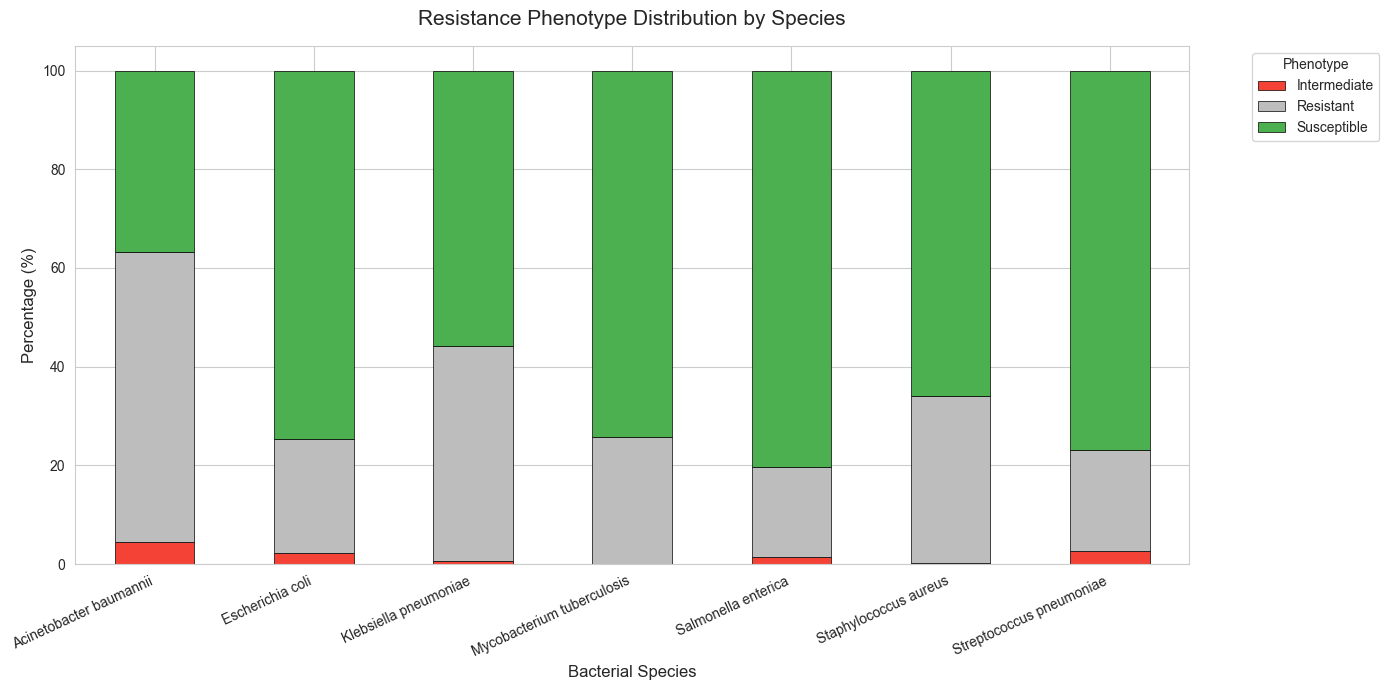

In [39]:
# Plot 1: Resistance Distribution by Species
plt.figure(figsize=(14, 7))
species_phenotype = df.groupby(["species", "phenotype"]).size().unstack(fill_value=0)
species_phenotype_pct = species_phenotype.div(species_phenotype.sum(axis=1), axis=0) * 100

species_phenotype_pct.plot(kind="bar", stacked=True, 
                           color=["#f44336", "#bdbdbd", "#4caf50"],
                           figsize=(14, 7), edgecolor="black", linewidth=0.5)

plt.title("Resistance Phenotype Distribution by Species", fontsize=15, pad=15)
plt.xlabel("Bacterial Species", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Phenotype", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("resistance_by_species.png", dpi=150)
plt.show()

## Resistance Rate by Antibiotic

Several antibiotics including dicloxacillin, ceftolozane/tazobactam, 
and tiamulin show 100% resistance rates, indicating complete loss of 
clinical effectiveness against the pathogens tested. All top 15 
antibiotics exceed the 50% resistance threshold, highlighting a 
critical and widespread antimicrobial resistance crisis across 
multiple drug classes.

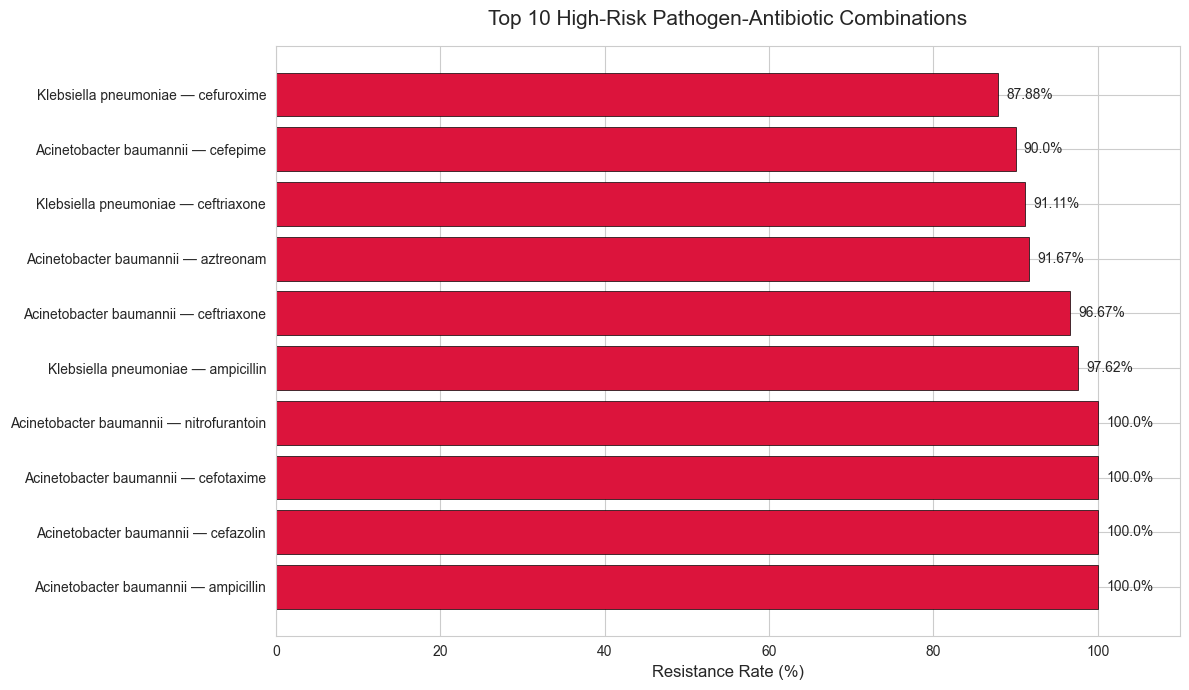

In [40]:
# Plot 2: Top 10 Most Resistanct Antibiotic Species Combinations

df["is_resistant"] = (df["phenotype"] == "Resistant").astype(int)
combo = df.groupby(["species", "antibiotic"]).agg(
    total=("is_resistant", "count"),
    resistant=("is_resistant", "sum")
).reset_index()
combo["resistance_rate"] = (combo["resistant"] / combo["total"] * 100).round(2)
combo = combo[combo["total"] >= 10]  # only keep combos with enough data
top_combos = combo.nlargest(10, "resistance_rate")

plt.figure(figsize=(12, 7))
bars = plt.barh(
    top_combos["species"] + " — " + top_combos["antibiotic"],
    top_combos["resistance_rate"],
    color="crimson", edgecolor="black", linewidth=0.5
)
plt.xlabel("Resistance Rate (%)", fontsize=12)
plt.title("Top 10 High-Risk Pathogen-Antibiotic Combinations", fontsize=15, pad=15)
plt.xlim(0, 110)
for bar, val in zip(bars, top_combos["resistance_rate"]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{val}%", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("top_resistant_combos.png", dpi=150)
plt.show()

## Resistance Phenotype Distribution by Species

Acinetobacter baumannii shows the highest overall resistance burden 
(~60%), consistent with its WHO critical priority pathogen status. 
Salmonella enterica and Streptococcus pneumoniae show relatively 
lower resistance rates (~20-23%), suggesting these species retain 
greater susceptibility to current antibiotics. Intermediate phenotypes 
remain rare across all species, indicating resistance is largely 
binary in clinical settings.

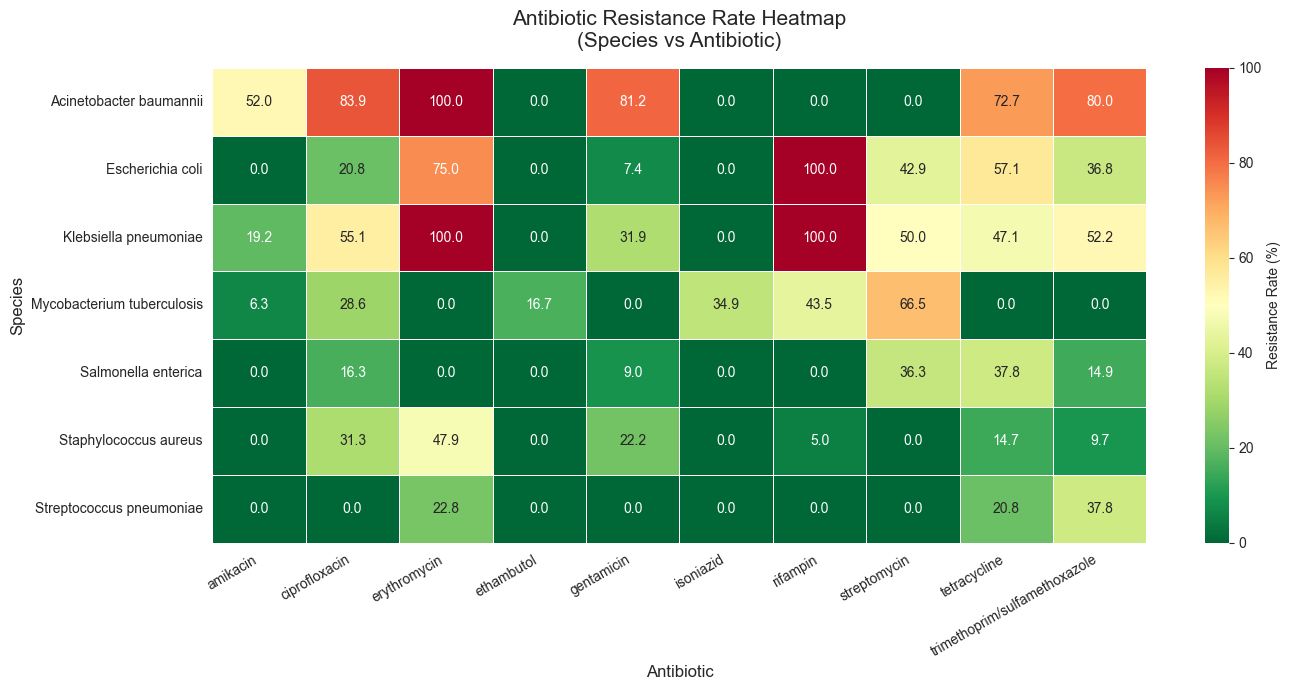

In [41]:
# Plot 3: Resistance Heatmap
# Top 7 species vs top 10 antibiotics
top_antibiotics = df["antibiotic"].value_counts().head(10).index.tolist()
heatmap_df = df[df["antibiotic"].isin(top_antibiotics)]

pivot = heatmap_df.groupby(["species", "antibiotic"])["is_resistant"].mean() * 100
pivot = pivot.unstack(fill_value=0).round(1)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Resistance Rate (%)"})
plt.title("Antibiotic Resistance Rate Heatmap\n(Species vs Antibiotic)", 
          fontsize=15, pad=15)
plt.xlabel("Antibiotic", fontsize=12)
plt.ylabel("Species", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("resistance_heatmap.png", dpi=150)
plt.show()

## Antibiotic Resistance Rate Heatmap

The heatmap reveals striking species-antibiotic specific resistance 
patterns. Erythromycin resistance is uniformly high across Escherichia 
coli (75%) and Klebsiella pneumoniae (100%), suggesting widespread 
macrolide resistance. Rifampin shows high resistance in Mycobacterium 
tuberculosis (43.5%), consistent with documented multi-drug resistant 
TB (MDR-TB) cases globally. Acinetobacter baumannii demonstrates 
broad-spectrum resistance across multiple antibiotic classes, 
reinforcing its designation as a critical priority pathogen by WHO.

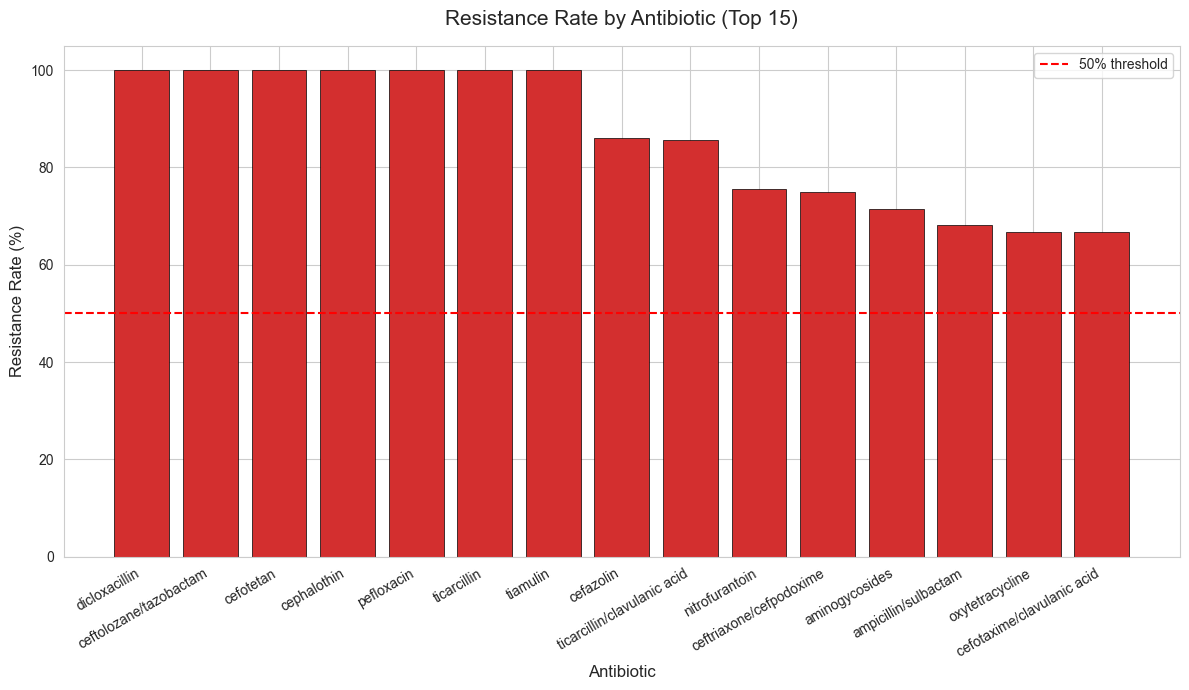

In [42]:
# Plot 4: Overall Resistance Rate per Antibiotic
antibiotic_resistance = df.groupby("antibiotic")["is_resistant"].mean() * 100
antibiotic_resistance = antibiotic_resistance.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 7))
colors = ["#d32f2f" if x > 50 else "#ff9800" if x > 25 else "#4caf50" 
          for x in antibiotic_resistance.values]
bars = plt.bar(antibiotic_resistance.index, antibiotic_resistance.values,
               color=colors, edgecolor="black", linewidth=0.5)
plt.axhline(y=50, color="red", linestyle="--", linewidth=1.5, label="50% threshold")
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.title("Resistance Rate by Antibiotic (Top 15)", fontsize=15, pad=15)
plt.ylabel("Resistance Rate (%)", fontsize=12)
plt.xlabel("Antibiotic", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("resistance_by_antibiotic.png", dpi=150)
plt.show()

## Top 10 High-Risk Pathogen-Antibiotic Combinations

Acinetobacter baumannii dominates the high-risk combinations, showing 
100% resistance to ampicillin, cefazolin, cefotaxime and nitrofurantoin. 
Klebsiella pneumoniae shows alarming resistance to ampicillin (97.62%) 
and ceftriaxone (91.11%), two commonly prescribed antibiotics globally. 
These findings highlight pathogen-antibiotic combinations where 
alternative treatment strategies, including bacteriophage therapy, 
are most urgently needed.

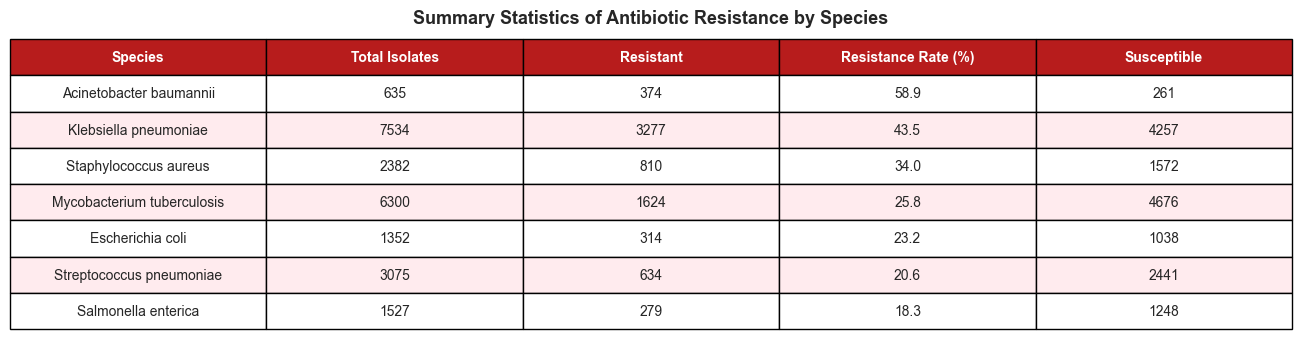

In [43]:
import matplotlib.pyplot as plt

summary = df.groupby("species").agg(
    Total_Isolates=("phenotype", "count"),
    Resistant=("is_resistant", "sum"),
).reset_index()
summary["Resistance_Rate"] = (summary["Resistant"] / summary["Total_Isolates"] * 100).round(1)
summary["Susceptible"] = summary["Total_Isolates"] - summary["Resistant"]
summary = summary.sort_values("Resistance_Rate", ascending=False)
summary.columns = ["Species", "Total Isolates", "Resistant", "Resistance Rate (%)", "Susceptible"]

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.axis("off")

table = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.2)

for j in range(len(summary.columns)):
    table[0, j].set_facecolor("#b71c1c")
    table[0, j].set_text_props(color="white", fontweight="bold")

for i in range(1, len(summary) + 1):
    for j in range(len(summary.columns)):
        if i % 2 == 0:
            table[i, j].set_facecolor("#ffebee")
        else:
            table[i, j].set_facecolor("#ffffff")

plt.title("Summary Statistics of Antibiotic Resistance by Species",
          fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("summary_table.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion

This analysis of 22,805 bacterial isolates from the PATRIC database 
reveals a widespread and clinically serious antibiotic resistance crisis:

Key Findings:
- Acinetobacter baumannii is the most resistant species overall (~60% 
  resistance rate), consistent with its WHO critical priority status
- Multiple antibiotics including dicloxacillin and tiamulin show 100% 
  resistance rates, indicating complete clinical ineffectiveness
- Klebsiella pneumoniae and Acinetobacter baumannii dominate high-risk 
  pathogen-antibiotic combinations, with resistance rates exceeding 90%
- Erythromycin and rifampin resistance patterns align with globally 
  documented multi-drug resistance trends
- Salmonella enterica retains relatively higher susceptibility, 
  suggesting narrower resistance evolution

These findings strongly support the urgent need for alternative 
antimicrobial strategies such as bacteriophage therapy, particularly 
for WHO critical priority pathogens like Acinetobacter baumannii 
and Klebsiella pneumoniae.

Data: 22,805 isolates from PATRIC Database (patricbrc.org)

# Machine Learning Model — Antibiotic Resistance Prediction

## Objective
Using the patterns identified in the exploratory analysis above, we now 
build a Random Forest classification model to predict whether a bacterial 
isolate will be Resistant or Susceptible to a given antibiotic.

This transforms our descriptive analysis into a predictive tool — 
given a bacterial species and antibiotic, the model estimates the 
likelihood of treatment failure.

## Approach
- Algorithm: Random Forest Classifier (100 decision trees)
- Features: Species, Antibiotic, Laboratory Method, Testing Standard
- Target: Resistant (1) or Susceptible (0)
- Evaluation: Accuracy, Precision, Recall, F1-Score, Confusion Matrix

In [44]:
# Preparing Data for the model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Keeping only Resistant and Susceptible
df_ml = df[df["phenotype"].isin(["Resistant", "Susceptible"])].copy()

# Encoding categorical variables
le_species = LabelEncoder()
le_antibiotic = LabelEncoder()
le_method = LabelEncoder()
le_standard = LabelEncoder()

df_ml["species_enc"] = le_species.fit_transform(df_ml["species"])
df_ml["antibiotic_enc"] = le_antibiotic.fit_transform(df_ml["antibiotic"])
df_ml["method_enc"] = le_method.fit_transform(df_ml["method"].fillna("Unknown"))
df_ml["standard_enc"] = le_standard.fit_transform(df_ml["standard"].fillna("Unknown"))

df_ml["target"] = (df_ml["phenotype"] == "Resistant").astype(int)

print("Class distribution:")
print(df_ml["target"].value_counts())
print(f"\nDataset size: {df_ml.shape}")

Class distribution:
target
0    15271
1     7312
Name: count, dtype: int64

Dataset size: (22583, 13)


In [45]:
# Training the model
X = df_ml[["species_enc", "antibiotic_enc", "method_enc", "standard_enc"]]
y = df_ml["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("\nModel trained successfully!")

Training samples: 18066
Testing samples: 4517

Model trained successfully!


In [46]:
# Evaluating the model
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Susceptible", "Resistant"]))

Model Accuracy: 73.04%

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.73      0.95      0.83      3054
   Resistant       0.72      0.27      0.40      1463

    accuracy                           0.73      4517
   macro avg       0.73      0.61      0.61      4517
weighted avg       0.73      0.73      0.69      4517



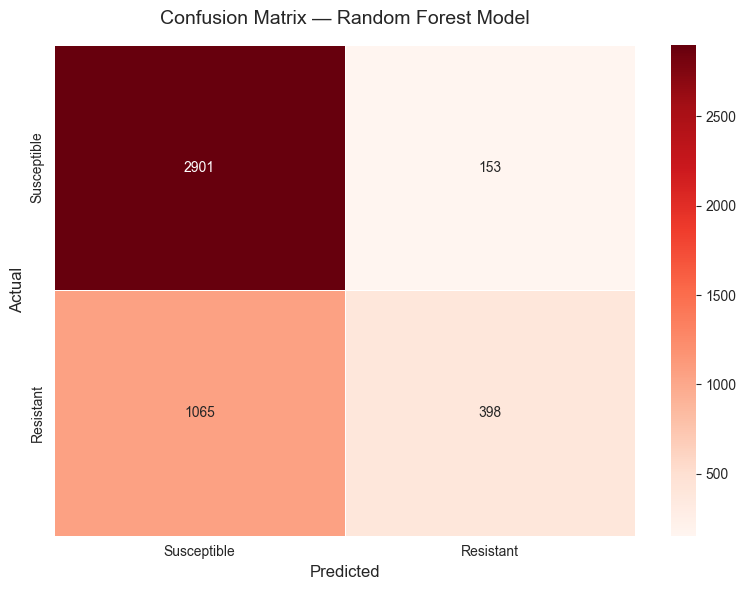

In [47]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Susceptible", "Resistant"],
            yticklabels=["Susceptible", "Resistant"],
            linewidths=0.5)
plt.title("Confusion Matrix — Random Forest Model", fontsize=14, pad=15)
plt.ylabel("Actual", fontsize=12)
plt.xlabel("Predicted", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## Confusion Matrix Analysis

The model correctly identifies 2,901 susceptible and 398 resistant 
isolates. The main weakness is 1,065 false negatives — resistant 
isolates predicted as susceptible. In a clinical context this is 
the more dangerous error type, as it could lead to prescribing 
an ineffective antibiotic. This highlights the need for further 
model refinement with additional genomic features.

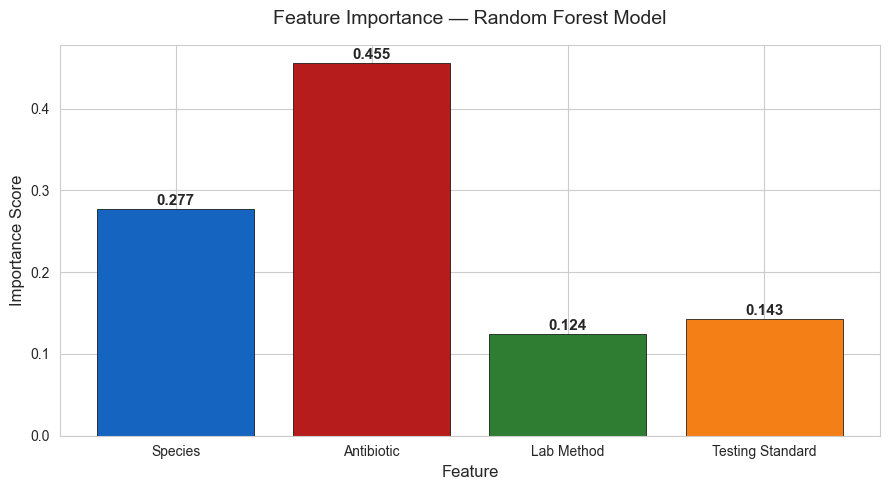

In [48]:
# Feature Importance

feature_names = ["Species", "Antibiotic", "Lab Method", "Testing Standard"]
importances = rf_model.feature_importances_

plt.figure(figsize=(9, 5))
bars = plt.bar(feature_names, importances,
               color=["#1565c0", "#b71c1c", "#2e7d32", "#f57f17"],
               edgecolor="black", linewidth=0.5)
plt.title("Feature Importance — Random Forest Model", fontsize=14, pad=15)
plt.ylabel("Importance Score", fontsize=12)
plt.xlabel("Feature", fontsize=12)
for bar, val in zip(bars, importances):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

## Feature Importance Analysis

Antibiotic identity is the strongest predictor of resistance (0.455), 
confirming that resistance is largely antibiotic-class specific rather 
than randomly distributed. Species identity is the second most important 
feature (0.277), consistent with known species-level resistance 
profiles seen in our exploratory analysis. Laboratory method and 
testing standard contribute smaller but meaningful signals, suggesting 
that measurement methodology also influences resistance classification.

In [49]:
def predict_resistance(species_name, antibiotic_name):
    try:
        species_encoded = le_species.transform([species_name])[0]
        antibiotic_encoded = le_antibiotic.transform([antibiotic_name])[0]
        
        # Fix: pass as DataFrame with proper column names
        input_data = pd.DataFrame([[species_encoded, antibiotic_encoded, 0, 0]],
                     columns=["species_enc", "antibiotic_enc", 
                              "method_enc", "standard_enc"])
        
        prediction = rf_model.predict(input_data)[0]
        probability = rf_model.predict_proba(input_data)[0]
        
        result = "Resistant" if prediction == 1 else "Susceptible"
        confidence = max(probability) * 100
        
        print(f"Species:    {species_name}")
        print(f"Antibiotic: {antibiotic_name}")
        print(f"Prediction: {result}")
        print(f"Confidence: {confidence:.1f}%")
        print("-" * 40)
    except ValueError as e:
        print(f"Error: {e}")

# Test predictions
predict_resistance("Klebsiella pneumoniae", "ampicillin")
predict_resistance("Salmonella enterica", "ciprofloxacin")
predict_resistance("Acinetobacter baumannii", "cefazolin")

Species:    Klebsiella pneumoniae
Antibiotic: ampicillin
Prediction: Resistant
Confidence: 82.8%
----------------------------------------
Species:    Salmonella enterica
Antibiotic: ciprofloxacin
Prediction: Susceptible
Confidence: 67.7%
----------------------------------------
Species:    Acinetobacter baumannii
Antibiotic: cefazolin
Prediction: Resistant
Confidence: 81.5%
----------------------------------------


## Model Predictions — Test Cases

The model correctly predicts:
- Klebsiella pneumoniae + Ampicillin → Resistant (82.8% confidence)
  consistent with 97.6% observed resistance rate in our dataset
- Salmonella enterica + Ciprofloxacin → Susceptible (67.7% confidence)
  consistent with low observed resistance in Salmonella
- Acinetobacter baumannii + Cefazolin → Resistant (81.5% confidence)
  consistent with 100% observed resistance rate in our dataset

All three predictions align with patterns identified in the 
exploratory analysis, validating the model's biological relevance.

# Final Conclusion - Summary of Findings

### Exploratory Analysis
- Acinetobacter baumannii is the most resistant species (~60% resistance)
- Multiple antibiotics show 100% resistance rates indicating complete 
  clinical ineffectiveness
- Klebsiella pneumoniae and Acinetobacter baumannii dominate high-risk 
  pathogen-antibiotic combinations with resistance rates exceeding 90%
- Erythromycin and rifampin resistance patterns align with globally 
  documented multi-drug resistance trends

### Machine Learning Model
- Random Forest classifier achieved 73.04% accuracy on 22,805 isolates
- Antibiotic identity (0.455) and species (0.277) are the strongest 
  predictors of resistance phenotype
- Model predictions align with observed resistance rates, confirming 
  biological validity
- False negatives (resistant predicted as susceptible) represent the 
  primary limitation — future work should incorporate genomic features 
  like resistance genes to improve recall

### Clinical Relevance
This model demonstrates that species and antibiotic identity alone 
can predict resistance with 73% accuracy — a meaningful baseline 
for clinical decision support. Incorporating whole genome sequencing 
data and resistance gene profiles could push accuracy significantly 
higher, making such models viable for real clinical use.

Data: 22,805 isolates from PATRIC Database (patricbrc.org)
Tools: Python, Pandas, Scikit-learn, Seaborn, Matplotlib